# Travel Company Customer Churn Prediction

### Neural Network Approach using TensorFlow/Keras

**Author:** Rıza Talebi
**Project Type:** Binary Classification / Customer Retention Analytics

## Business Problem

Travel companies lose revenue when customers stop using their services. The goal of this project is to build a **neural network model** that predicts whether a customer is likely to churn based on demographic information and service usage behavior.

### Why is this important?

Early churn prediction allows travel companies to:

- Launch retention campaigns
- Offer personalized discounts
- Improve customer engagement
- Reduce revenue loss
- Increase customer lifetime value

## Importing Libraries
 **Make sure you have all libraries installed. if not run 'pip install pandas matplotlib numpy seaborn scikit-learn tensorflow' in your terminal**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

/Users/rizatalebi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 📊 Dataset Overview

The dataset contains **954 customer records** with the following features:

| Feature | Description |
|---|---|
| Age | Customer age |
| FrequentFlyer | Whether the customer is a frequent flyer |
| AnnualIncomeClass | Income category |
| ServicesOpted | Number of services used |
| AccountSyncedToSocialMedia | Social media synchronization status |
| BookedHotelOrNot | Whether the customer booked a hotel |
| Target | Churn label (0 = Stay, 1 = Churn) |

This is a **binary classification problem** because the target variable has two possible outcomes.

## Loading Dataset and Checking for information

In [2]:
df = pd.read_csv('Customertravel.csv')
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         954 non-null    int64 
 1   FrequentFlyer               954 non-null    object
 2   AnnualIncomeClass           954 non-null    object
 3   ServicesOpted               954 non-null    int64 
 4   AccountSyncedToSocialMedia  954 non-null    object
 5   BookedHotelOrNot            954 non-null    object
 6   Target                      954 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 52.3+ KB


,Age,ServicesOpted,Target
count,954.000000,954.000000,954.000000
mean,32.109015,2.437107,0.234801
std,3.337388,1.606233,0.424097
min,27.000000,1.000000,0.000000
25%,30.000000,1.000000,0.000000
50%,31.000000,2.000000,0.000000
75%,35.000000,4.000000,0.000000
max,38.000000,6.000000,1.000000


## Preprocess

In [3]:

X = df.drop('Target', axis=1)
y = df['Target']

# Convert categorical columns to numbers
X = pd.get_dummies(X, drop_first=True)

print(X.head())
print()
print(X.columns)

   Age  ServicesOpted  FrequentFlyer_No Record  FrequentFlyer_Yes  \
0   34              6                    False              False   
1   34              5                    False               True   
2   37              3                    False              False   
3   30              2                    False              False   
4   30              1                    False              False   

   AnnualIncomeClass_Low Income  AnnualIncomeClass_Middle Income  \
0                         False                             True   
1                          True                            False   
2                         False                             True   
3                         False                             True   
4                          True                            False   

   AccountSyncedToSocialMedia_Yes  BookedHotelOrNot_Yes  
0                           False                  True  
1                            True                 False  
2 

## spliting data for Train / Test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print('Training samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])

Training samples: 667
Test samples: 287


In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:3])

[[ 0.88497535  2.30326537 -0.26575553 -0.65909681 -0.84537149  1.18291191
  -0.78672234  1.22781057]
 [-0.90465141 -0.88007073 -0.26575553 -0.65909681 -0.84537149  1.18291191
   1.27109649  1.22781057]
 [-0.90465141 -0.24340351 -0.26575553 -0.65909681  1.18291191 -0.84537149
   1.27109649 -0.81445788]]


#### Building The Model (More data on Github Repo)

In [6]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model.summary() #used for Checking the model

/Users/rizatalebi/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Train and Visualize Training

In [8]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3303 - loss: 0.9184 - val_accuracy: 0.3209 - val_loss: 0.7911
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3806 - loss: 0.8428 - val_accuracy: 0.4403 - val_loss: 0.7234
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5003 - loss: 0.7237 - val_accuracy: 0.6194 - val_loss: 0.6740
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6070 - loss: 0.6655 - val_accuracy: 0.7313 - val_loss: 0.6349
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6077 - loss: 0.6564 - val_accuracy: 0.7164 - val_loss: 0.6042
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6852 - loss: 0.6190 - val_accuracy: 0.7239 - val_loss: 0.5797
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6980 - loss: 0.5784 - val_accuracy: 0.7313 - val_loss: 0.5567
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7131 - loss: 0.5629 - val_accuracy: 0.7313 - val_loss

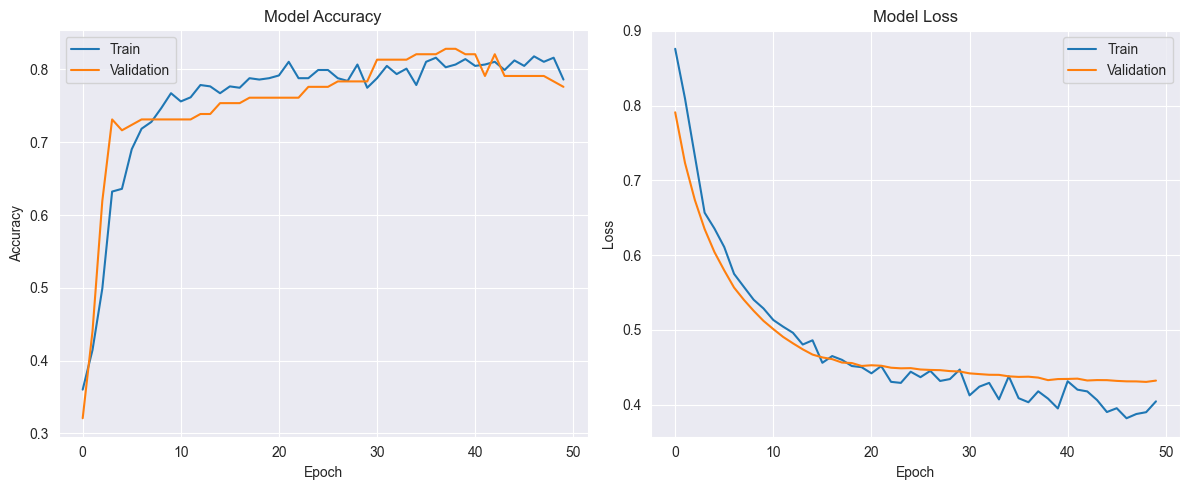

In [9]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluate on test data

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Test Accuracy: {test_accuracy:.4f}')

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8621 - loss: 0.3417 
Test Accuracy: 0.8467


#### Confusion matrix

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


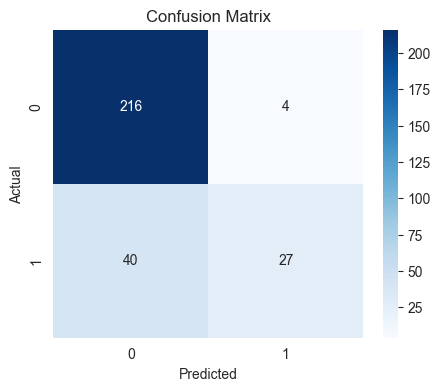

              precision    recall  f1-score   support

           0       0.84      0.98      0.91       220
           1       0.87      0.40      0.55        67

    accuracy                           0.85       287
   macro avg       0.86      0.69      0.73       287
weighted avg       0.85      0.85      0.82       287



In [11]:

y_prob = model.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_prob > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))

## A sample prediction

In [12]:
# Take one customer from the test set
sample = X_test[0].reshape(1, -1)

probability = model.predict(sample)[0][0]

print(f'Churn probability: {probability:.2%}')

if probability > 0.5:
    print('⚠️ Customer is likely to churn')
else:
    print('✅ Customer is likely to stay')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Churn probability: 1.81%
✅ Customer is likely to stay


In [13]:
model.save('travel_churn_model.keras')

In [14]:
plt.savefig('accuracy_curve.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>